<ipython-input-2-f668ab8f9ad7>:8: RuntimeWarning: overflow encountered in double_scalars
  return -1000.0*y + 3000.0 - 2000.0*np.exp(-t)
<ipython-input-2-f668ab8f9ad7>:28: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


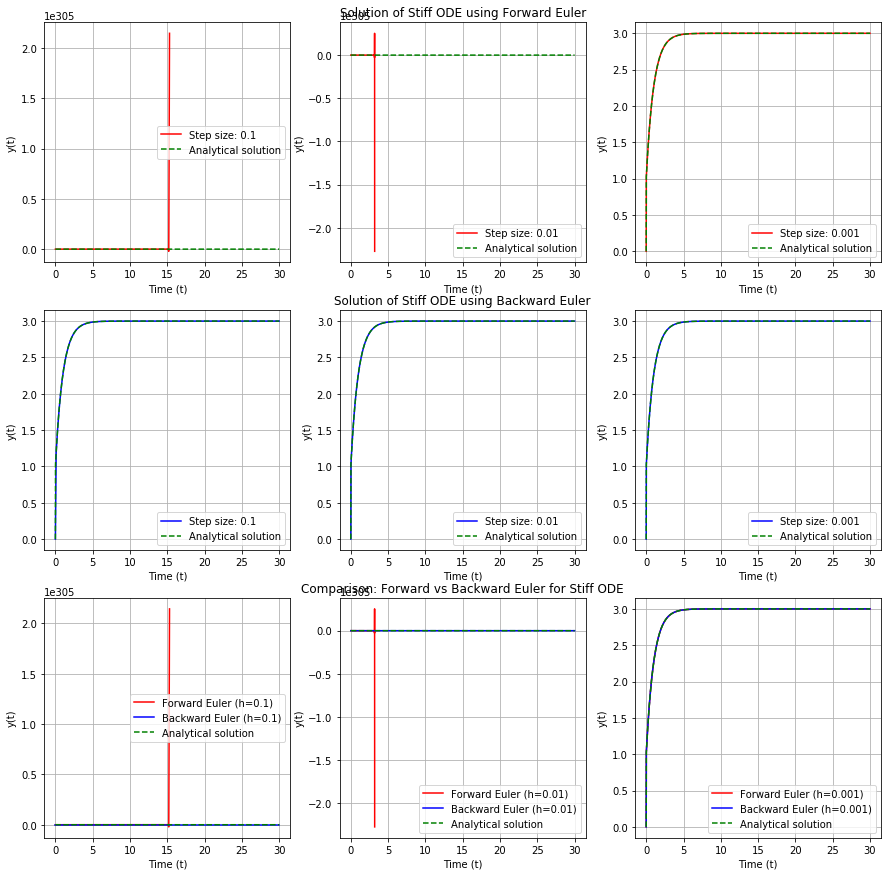

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


def f(t, y):
    """Function representing the ODE dy/dt = -1000y + 3000 - 2000e^(-t)"""
    return -1000.0*y + 3000.0 - 2000.0*np.exp(-t)


def analytical_solution(t0, tf, h):
    """Analytical solution of above function with initial condition y(0)=0

    y(t) = 3 - 0.998e^(-1000t) -2.002e^(-t)
    """
    t_values = np.arange(t0, tf + h, h)
    y_values = 3.0 - 0.998*np.exp(-1000*t_values) - 2.002*np.exp(-t_values)
    return t_values, y_values


def forward_euler(t0, tf, h):
    """Forward Euler method solver of the function"""
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = 0.0  # y(0) = 0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
    return t_values, y_values


def backward_euler(t0, tf, h):
    """Backward Euler method solver of the function"""
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = 0.0  # y(0) = 0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)
    return t_values, y_values


# Parameters
t0 = 0.0
tf = 30.0
h_values = np.array([0.1, 0.01, 0.001], dtype=float)

# Setup plot
plt.figure(figsize=[15.0, 15.0])
subplots = [[plt.subplot(3, h_values.size, i*3+j+1) for j in range(h_values.size)] for i in range(3)]
i_mid = h_values.size // 2
subplots[0][i_mid].set_title('Solution of Stiff ODE using Forward Euler')
subplots[1][i_mid].set_title('Solution of Stiff ODE using Backward Euler')
subplots[2][i_mid].set_title('Comparison: Forward vs Backward Euler for Stiff ODE')

# Calculate analytical solution
t_exact, y_exact = analytical_solution(t0, tf, np.min(h_values))

# Solve and plot with Euler's method
for i, h in enumerate(h_values):
    # Solve the ODE
    t_values_f, y_values_f = forward_euler(t0, tf, h)
    t_values_b, y_values_b = backward_euler(t0, tf, h)

    # Plot the results
    subplots[0][i].plot(t_values_f, y_values_f, 'r-', label=f'Step size: {h}')
    subplots[1][i].plot(t_values_b, y_values_b, 'b-', label=f'Step size: {h}')
    subplots[2][i].plot(t_values_f, y_values_f, 'r-', label=f'Forward Euler (h={h})')
    subplots[2][i].plot(t_values_b, y_values_b, 'b-', label=f'Backward Euler (h={h})')
    for j in range(3):
        subplots[j][i].plot(t_exact, y_exact, 'g--', label="Analytical solution")
        subplots[j][i].set_xlabel('Time (t)')
        subplots[j][i].set_ylabel('y(t)')
        subplots[j][i].legend()
        subplots[j][i].grid(True)
plt.show()